# Inference Notebook
- This notebook imports a trained model and generates new samples.
- Edit the Checkpoint and Configs cell plus the sample-parameter cells to run your own inference.
- This version supports conditional generation for bass, guitar, and keyboard.
- Have fun creating new sounds!

*(NOTE: Do not use Run All in this notebook; run cells section-by-section.)*

#### Imports
Import necessary libraries to run the notebook

In [21]:
# Imports
import importlib
import matplotlib.pyplot as plt
import torch
import torchaudio
import IPython.display as ipd

import main.inference_helpers as inference_helpers

inference_helpers = importlib.reload(inference_helpers)
load_inference_context = inference_helpers.load_inference_context
prepare_audio_for_display = inference_helpers.prepare_audio_for_display
plot_mel_spectrogram = inference_helpers.plot_mel_spectrogram
prepare_conditioning_inputs = inference_helpers.prepare_conditioning_inputs
resolve_reference_waveform = inference_helpers.resolve_reference_waveform
generate_unconditional_samples = inference_helpers.generate_unconditional_samples
generate_conditional_samples_from_reference = inference_helpers.generate_conditional_samples_from_reference


### Checkpoint & Configs
- Replace these paths with the path to your model's checkpoint and configs.
- Pre-trained models are availlable to download on Hugging Face.

|Model|Link|
|---|---|
|Kicks|[crlandsc/tiny-audio-diffusion-kicks](https://huggingface.co/crlandsc/tiny-audio-diffusion-kicks)|
|Snares|[crlandsc/tiny-audio-diffusion-snares](https://huggingface.co/crlandsc/tiny-audio-diffusion-snares)|
|Hi-hats|[crlandsc/tiny-audio-diffusion-hihats](https://huggingface.co/crlandsc/tiny-audio-diffusion-hihats)|
|Percussion (all drum types)|[crlandsc/tiny-audio-diffusion-percussion](https://huggingface.co/crlandsc/tiny-audio-diffusion-percussion)|

In [26]:
# Inference settings mapped to scripts/train_conditional_models.sh runs
# - onehot: ConditionalModel + onehot + no contrastive
# - contrastive: EmbeddingConditionalModel + label_embedding + contrastive
model_variants = {
    "onehot": {
        "config_path": "exp/nsynth_conditional_16gb_no_wandb.yaml",
        "ckpt_path": "logs/ckpts/2026-04-19-17-22-41/epoch=141-valid_loss=0.033.ckpt",
        "conditioning_mode_override": "onehot",
    },
    "contrastive": {
        "config_path": "exp/nsynth_conditional_16gb_embedding_no_wandb.yaml",
        "ckpt_path": "logs/ckpts/2026-04-19-19-01-59/epoch=702-valid_loss=0.033.ckpt",
        "conditioning_mode_override": "label_embedding",
    },
}

active_model = "contrastive"  # onehot | contrastive
if active_model not in model_variants:
    raise ValueError(f"Unknown active_model '{active_model}'. Use one of {list(model_variants.keys())}.")

config_path = model_variants[active_model]["config_path"]
ckpt_path = model_variants[active_model]["ckpt_path"]
conditioning_mode_override = model_variants[active_model].get("conditioning_mode_override")

selected_class = "keyboard"  # bass | guitar | keyboard
reference_split = "test"     # train | valid | test
reference_index = None        # set integer to force a specific row
reference_pt_path = None      # set to a .pt waveform file to override dataset sample

num_samples = 1
num_steps = 250
noise_scale = 0.15
unconditional_noise_scale = 0.8   # matches previous unconditional behavior
seed = 456                        # sample 1 uses exactly this seed

print("Active model:", active_model)
print("Config path:", config_path)
print("Checkpoint:", ckpt_path)
print("Conditioning mode override:", conditioning_mode_override)
print("Selected class:", selected_class)
print("Reference split:", reference_split)
print("Reference pt path:", reference_pt_path)


Active model: contrastive
Config path: exp/nsynth_conditional_16gb_embedding_no_wandb.yaml
Checkpoint: logs/ckpts/2026-04-19-19-01-59/epoch=702-valid_loss=0.033.ckpt
Conditioning mode override: label_embedding
Selected class: keyboard
Reference split: test
Reference pt path: None


### Step 2: Load Inference Context
Load the selected checkpoint and config into a ready-to-sample context.

In [23]:
# Load the configured model and the conditional metadata-backed datamodule.
context = load_inference_context(
    config_path,
    ckpt_path,
    conditioning_mode_override=conditioning_mode_override,
)
model = context.model
datamodule = context.datamodule
class_names = context.class_names
conditioning_mode = context.conditioning_mode
conditioning_dim = context.conditioning_dim
sample_rate = context.sample_rate
sample_length = context.sample_length
audio_channels = context.audio_channels

use_contrastive_loss = bool(context.config.get("model", {}).get("use_contrastive_loss", False))

print(f"Loaded variant: {active_model}")
print(f"Loaded config: {context.config_path}")
print(f"Conditional model: {context.is_conditional} | embedding model: {context.is_embedding_model}")
print(f"Conditioning mode: {conditioning_mode} | classes: {class_names}")
print(f"Contrastive loss enabled in config: {use_contrastive_loss}")
print(f"Sample rate: {sample_rate} | length: {sample_length} | channels: {audio_channels}")
print(f"Device: {model.device}")


Loaded variant: contrastive
Loaded config: exp/nsynth_conditional_16gb_embedding_no_wandb.yaml
Conditional model: True | embedding model: True
Conditioning mode: label_embedding | classes: ['bass', 'guitar', 'keyboard']
Contrastive loss enabled in config: True
Sample rate: 16000 | length: 16384 | channels: 1
Device: cuda:0


In [ ]:
# Runtime parameters summary.
sample_length = context.sample_length
sr = context.sample_rate
audio_channels = context.audio_channels

print("sample_length:", sample_length)
print("sr:", sr)
print("audio_channels:", audio_channels)
print("reference_pt_path:", reference_pt_path)
print("num_samples:", num_samples)
print("num_steps:", num_steps)
print("unconditional_noise_scale:", unconditional_noise_scale)
print("noise_scale:", noise_scale)


sample_length: 16384
sr: 16000
audio_channels: 1
reference_pt_path: None


In [ ]:
# Conditional reference and class settings.
print("selected_class:", selected_class)
print("reference_split:", reference_split)
print("reference_index:", reference_index)
print("reference_pt_path:", reference_pt_path)
print("num_samples:", num_samples)
print("num_steps:", num_steps)
print("noise_scale:", noise_scale)


Selected class: keyboard
Reference split: test
Reference index override: None


### Unconditional Generation
Run this cell to generate samples from pure noise (no class conditioning).

Active model: contrastive
Inference conditioning mode: label_embedding
Unconditional sample 1 | seed=456 | steps=250 | noise_scale=0.8


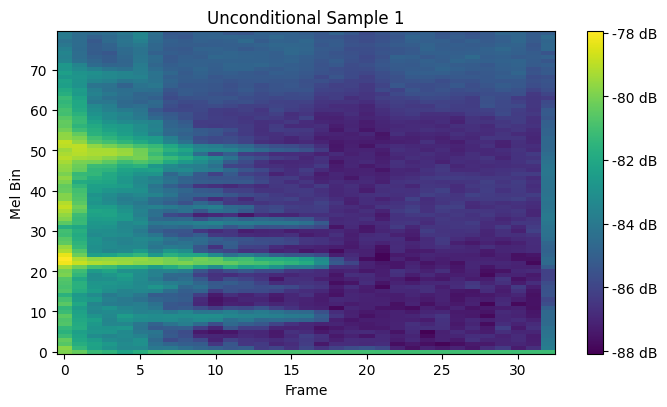

In [27]:
# Unconditional generation only.
print(f"Active model: {active_model}")
print(f"Inference conditioning mode: {conditioning_mode}")

unconditional_samples = generate_unconditional_samples(
    context,
    num_samples=num_samples,
    num_steps=num_steps,
    seed=seed,
    noise_scale=unconditional_noise_scale,
)

for sample_index, unconditional_sample in enumerate(unconditional_samples, start=1):
    unconditional_audio = prepare_audio_for_display(unconditional_sample)
    print(
        f"Unconditional sample {sample_index} | seed={seed + sample_index - 1} | "
        f"steps={num_steps} | noise_scale={unconditional_noise_scale}"
    )
    display(ipd.Audio(unconditional_audio.squeeze(0).numpy(), rate=sample_rate))
    plot_mel_spectrogram(unconditional_audio, sample_rate=sample_rate)
    plt.title(f"Unconditional Sample {sample_index}")
    plt.show()


### Step 5: Conditional Generation
Generate class-conditioned outputs from a reference waveform, and display reference, noised input, and generated audio.

Active model: contrastive
Conditioning mode used for inference: label_embedding
Class id tensor: (1,)
Conditioning tensor: None (label_embedding mode uses class_ids)
Reference row class: keyboard
Reference source: test/41
Selected class for conditional generation: keyboard
Reference clean input


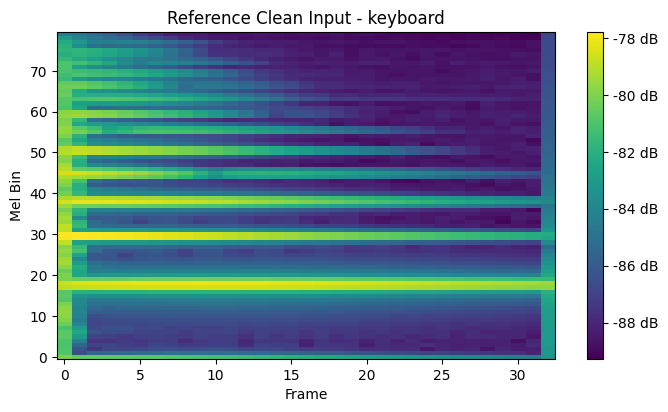

Actual conditional input to model (noised) - sample 1


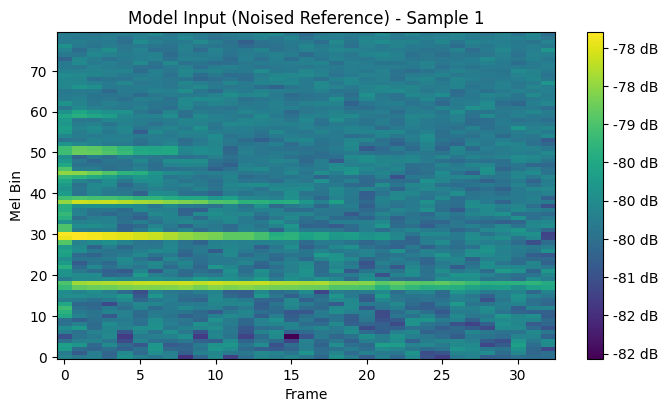

Generated sample 1 | class=keyboard | mode=label_embedding


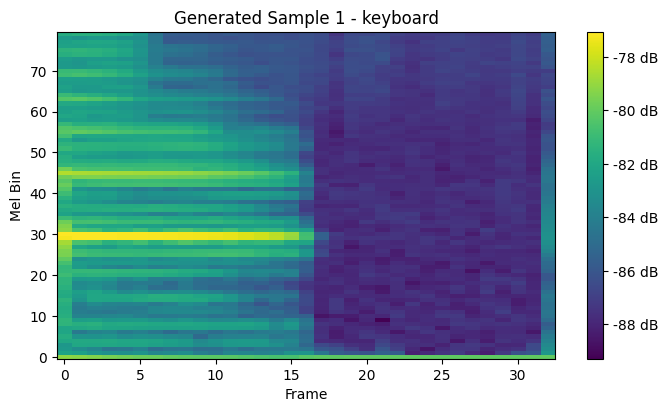

In [25]:
# Conditional generation only.
if context.datamodule is None and reference_pt_path is None:
    raise ValueError("Set reference_pt_path to a .pt waveform or load a config with a conditional datamodule.")

class_id, conditioning_for_model = prepare_conditioning_inputs(context, selected_class)
print(f"Active model: {active_model}")
print(f"Conditioning mode used for inference: {conditioning_mode}")
print(f"Class id tensor: {tuple(class_id.shape)}")
if conditioning_for_model is not None:
    print(f"Conditioning tensor: {tuple(conditioning_for_model.shape)}")
else:
    print("Conditioning tensor: None (label_embedding mode uses class_ids)")

seed_waveform, reference_label, reference_item = resolve_reference_waveform(
    context,
    class_name=selected_class,
    seed=seed,
    reference_split=reference_split,
    reference_index=reference_index,
    reference_pt_path=reference_pt_path,
)
if reference_item is not None:
    print(f"Reference row class: {reference_item['Class']}")

reference_audio = prepare_audio_for_display(seed_waveform)
print(f"Reference source: {reference_label}")
print(f"Selected class for conditional generation: {selected_class}")

print("Reference clean input")
display(ipd.Audio(reference_audio.squeeze(0).numpy(), rate=sample_rate))
plot_mel_spectrogram(reference_audio, sample_rate=sample_rate)
plt.title(f"Reference Clean Input - {selected_class}")
plt.show()

conditional_results = generate_conditional_samples_from_reference(
    context,
    class_id=class_id,
    conditioning_for_model=conditioning_for_model,
    reference_waveform=reference_audio,
    num_samples=num_samples,
    num_steps=num_steps,
    seed=seed,
    noise_scale=noise_scale,
)

for sample_index, result in enumerate(conditional_results, start=1):
    model_input_audio = prepare_audio_for_display(result["model_input"])
    print(f"Actual conditional input to model (noised) - sample {sample_index}")
    display(ipd.Audio(model_input_audio.squeeze(0).numpy(), rate=sample_rate))
    plot_mel_spectrogram(model_input_audio, sample_rate=sample_rate)
    plt.title(f"Model Input (Noised Reference) - Sample {sample_index}")
    plt.show()

    generated_audio = prepare_audio_for_display(result["generated"])
    print(f"Generated sample {sample_index} | class={selected_class} | mode={conditioning_mode}")
    display(ipd.Audio(generated_audio.squeeze(0).numpy(), rate=sample_rate))
    plot_mel_spectrogram(generated_audio, sample_rate=sample_rate)
    plt.title(f"Generated Sample {sample_index} - {selected_class}")
    plt.show()
